# Cross-Dataset Harmonization for Workplace Injury Data

**Author**: rab  
**Last Modified**: 2026-02-28

## Overview
This notebook documents a reproducible harmonization workflow for public workplace injury datasets used in our papers, "Characterizing and Harmonizing Five Public Workplace Injury Datasets for Research and Modeling" and "Datasets From Five Public Workplace Injury Sources With Cross-Dataset Harmonization for Research and Modeling." It standardizes source-specific fields into an integrated analytic schema, generates descriptive figures/tables, and runs a simple baseline classification experiment/demonstration (for example purposes).

## Scope
- dataset loading and standardization
- harmonized injury descriptors
- descriptive tables and figures
- exploratory baseline modeling outputs

## Data sources
- OSHA SIR: [Severe Injury Dashboard](https://www.osha.gov/severe-injury-reports)
- OSHA ITA: [OSHA Injury Tracking Application (ITA) Data](https://www.osha.gov/Establishment-Specific-Injury-and-Illness-Data)
- TX SV2: [Texas Institutional Medical Billing Services (SV2) Detail Information](https://data.texas.gov/dataset/Institutional-Medical-Billing-Services-SV2-Detail-/tuuc-49gz/about_data)
- OR WC: [Oregon Workers' Compensation Record Level Claims](https://catalog.data.gov/dataset/oregon-workers-compensation-record-level-claims)
- NY WC: [NY State Workers' Compensation Injury Claims](https://www.kaggle.com/datasets/thedevastator/new-york-state-workers-compensation-injury-claim)

## Expected local files (names and locations)

Place the following raw files, with names, in the same directory as this notebook before running:

- `SIR_RAW.csv`
- `SV2_RAW.csv`
- `OR_WC_RAW.csv`
- `NY_WC_RAW.csv`
- `ITA_RAW Case Detail Data 2023 through 12-31-2023.csv`
- `ITA_RAW Case Detail Data 2024 through 04-30-2025.csv`

## Reproducibility note

The notebook is written to preserve source fields where possible and to keep harmonization logic explicit in code. Narrative-based backfilling is only used where structured fields are absent and does not overwrite existing coded fields.

In [50]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re
import spacy
import string
from rapidfuzz import process, fuzz
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
#import xgboost as xgb
from sklearn.metrics import (roc_auc_score, roc_curve, auc,
                             average_precision_score, precision_recall_curve)
from sklearn.model_selection import GroupShuffleSplit

# Install the small English spaCy model before running, if needed:
# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

sns.set_theme(style="whitegrid", palette="viridis")

## Harmonization notes

We harmonize (integrate) four datasets (SIR, ITA, OR_WC, NY_WC) with a comparable unit of analysis which entails a workplace injury event or workers' compensation claim with an injury date and at least partial injury descriptors.

As such, the harmonized schema/taxonomy is intentionally high level, focusing on:
- `date_of_injury`
- `industry_description`
- `nature_category`
- `body_part_category`
- `event_category`
- source-traceable narrative or coded inputs when available

The goal is meaningful comparability across these public sources, not strict equivalence of case definition, severity, claim adjudication, or jurisdictional reporting practice. Given this, we provide a high-level view across jurisdications.

Note that `SV2` is excluded and not merged into the event-level harmonized analytic file. It represents medical billing line items rather than injury events.

In [4]:
# Load each raw source file used in the notebook.
sir = pd.read_csv('SIR_RAW.csv', low_memory=False)
orwc = pd.read_csv('OR_WC_RAW.csv', low_memory=False)
nywc = pd.read_csv('NY_WC_RAW.csv', low_memory=False)

# ITA is provided as multiple annual extracts, so read and concatenate them.
file_list = [
    "ITA_RAW Case Detail Data 2023 through 12-31-2023.csv",
    "ITA_RAW Case Detail Data 2024 through 04-30-2025.csv",
]
read_kwargs = {
    # "dtype_backend": "pyarrow",
    "low_memory": False,
    "encoding": "ISO-8859-1",
}
df_list = [pd.read_csv(os.path.join('', f), **read_kwargs) for f in file_list]
ita = pd.concat(df_list, ignore_index=True).reset_index(drop=True)

In [5]:
def clean_date(x):
    return pd.to_datetime(x, errors="coerce")

In [6]:
START_YEAR = 2015
END_YEAR = 2024

### ITA Standardization

OSHA ITA contributes event dates, NAICS, industry text, and free-text narratives, but it does not provide the structured injury descriptor fields used elsewhere in this notebook. Those fields are left missing at this stage and are only backfilled later from narratives.

In [7]:
ita_h = pd.DataFrame()

# Map ITA fields into the shared schema.
ita_h["date_of_injury"] = clean_date(ita["date_of_incident"])
ita_h["naics"] = ita["naics_code"]
ita_h["industry_description"] = ita["industry_description"]

ita_h = ita_h[(ita_h["date_of_injury"].dt.year >= START_YEAR) &
              (ita_h["date_of_injury"].dt.year <= END_YEAR)]

print(ita_h["date_of_injury"].min(), "--", ita_h["date_of_injury"].max())

# ITA does not provide structured nature, body-part, or event code fields in this workflow.
# Leave these missing here; a later step optionally infers categories from the `narrative` field.
ita_h["nature_code"] = np.nan
ita_h["body_part_code"] = np.nan
ita_h["event_code"] = np.nan
ita_h["narrative"] = ita["NEW_INCIDENT_DESCRIPTION"]
ita_h["source"] = "ITA"

2022-02-26 00:00:00 -- 2024-12-31 00:00:00


### SIR Standardization

OSHA SIR already contains structured injury descriptors aligned closely enough to support direct mapping into the harmonized categories. This source also includes narratives, which are preserved but are not needed as the primary coding source.

In [8]:
sir_h = pd.DataFrame()

# Map SIR fields into the shared schema.
sir_h["date_of_injury"] = clean_date(sir["EventDate"])
sir_h["naics"] = sir["Primary NAICS"]
sir_h["industry_description"] = np.nan  # not available in this extract

sir_h = sir_h[(sir_h["date_of_injury"].dt.year >= START_YEAR) &
              (sir_h["date_of_injury"].dt.year <= END_YEAR)]

print(sir_h["date_of_injury"].min(), "--", sir_h["date_of_injury"].max())

sir_h["nature_code"] = sir["NatureTitle"]
sir_h["body_part_code"] = sir["Part of Body Title"]
sir_h["event_code"] = sir["EventTitle"]
sir_h["narrative"] = sir["Final Narrative"]
sir_h["source"] = "SIR"

2015-01-01 00:00:00 -- 2024-12-31 00:00:00


### NY_WC Standardization

The New York workers' compensation extract includes partially overlapping WCIO and OIICS descriptor fields. The logic below prefers WCIO description fields when present and otherwise falls back to available OIICS descriptions.

In [13]:
ny_h = pd.DataFrame()

# Map NY_WC fields into the shared schema.
ny_h["date_of_injury"] = clean_date(nywc["Accident Date"])
ny_h["naics"] = np.nan   # no NAICS in this extract
ny_h["industry_description"] = np.nan

ny_h = ny_h[(ny_h["date_of_injury"].dt.year >= START_YEAR) &
            (ny_h["date_of_injury"].dt.year <= END_YEAR)]

print(ny_h["date_of_injury"].min(), "--", ny_h["date_of_injury"].max())

# Prefer WCIO text when available, then fall back to OIICS text.
ny_h["nature_code"] = (nywc["WCIO Nature of Injury Description"]
                       .fillna(nywc["OIICS Nature of Injury Description"])
                       .astype(str)
                       .replace(r'^\s*$', np.nan, regex=True)
                       .replace(r'^\s*(nan|NaN|NAN)\s*$', np.nan, regex=True)
                       # .str.replace("*", "", regex=False)
                       )

ny_h["body_part_code"] = (nywc["WCIO Part Of Body Description"]
                          .fillna(nywc["OIICS Part Of Body Description"])
                          .astype(str)
                          .replace(r'^\s*$', np.nan, regex=True)
                          .replace(r'^\s*(nan|NaN|NAN)\s*$', np.nan, regex=True)
                          # .str.replace("*", "", regex=False)
                          )

ny_h["event_code"] = (nywc["WCIO Cause of Injury Description"]
                      .fillna(nywc["OIICS Nature of Injury Description"])
                      .astype(str)
                      .replace(r'^\s*$', np.nan, regex=True)
                      .replace(r'^\s*(nan|NaN|NAN)\s*$', np.nan, regex=True)
                      # .str.replace("*", "", regex=False)
                      )

# No narrative field is used/available from this extract.
ny_h["narrative"] = np.nan
ny_h["source"] = "NY_WC"

2015-01-01 00:00:00 -- 2016-06-25 00:00:00


### OR_WC Standardization

The Oregon workers' compensation extract includes structured descriptor text and industry context, making it one of the more directly alignable sources in the harmonized file.

In [14]:
or_h = pd.DataFrame()

# Map OR_WC fields into the shared schema.
or_h["date_of_injury"] = clean_date(orwc["Date of Injury"])
or_h["naics"] = orwc["NAICS Code"]
or_h["industry_description"] = orwc["NAICS Code (Description)"]

or_h = or_h[(or_h["date_of_injury"].dt.year >= START_YEAR) &
            (or_h["date_of_injury"].dt.year <= END_YEAR)]

print(or_h["date_of_injury"].min(), "--", or_h["date_of_injury"].max())

# Clean structured descriptor text fields and preserve missing values explicitly.
or_h["nature_code"] = (orwc["Nature of Injury (Description)"]
                       .replace(r'^\s*$', np.nan, regex=True)
                       .replace(r'^\s*(nan|NaN|NAN)\s*$', np.nan, regex=True)
                       )
or_h["body_part_code"] = (orwc["Body Part Injured (Description)"]
                          .replace(r'^\s*$', np.nan, regex=True)
                          .replace(r'^\s*(nan|NaN|NAN)\s*$', np.nan, regex=True)
                          )
or_h["event_code"] = (orwc["Event of Injury (Description)"]
                      .replace(r'^\s*$', np.nan, regex=True)
                      .replace(r'^\s*(nan|NaN|NAN)\s*$', np.nan, regex=True)
                      )

# No narrative field is used from this extract.
or_h["narrative"] = np.nan
or_h["source"] = "OR_WC"

2015-01-01 00:00:00 -- 2022-10-01 00:00:00


/var/folders/9s/sth28l1x4mb61jw17qrj3qq80000gn/T/ipykernel_70243/2986154613.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(x, errors="coerce")


## Build Harmonized Dataset

The next cells concatenate the source-specific standardized tables and then assign shared event, nature, and body-part categories. Original source fields are preserved so that category assignments remain inspectable.

### Classification/Mapping Pipeline

The harmonization pipeline applies the following:
1. normalize free-text descriptor fields
2. attempt exact token matching
3. apply regex pattern matching
4. (optionally) apply fuzzy matching

This results in a set of harmonized category columns and human-readable labels for body part, nature of injury, and event/exposure.

In [15]:
harmonized = pd.concat([ita_h, sir_h, ny_h, or_h], ignore_index=True)

In [16]:
def _normalize_text(s):
    if pd.isna(s):
        return ''
    s = str(s).strip().lower()
    s = s.translate(str.maketrans('', '', ''.join(ch for ch in string.punctuation if ch not in '()')))
    s = re.sub(r'\s+', ' ', s)
    return s

def fuzzy_match(query, choices, threshold=85, scorer=fuzz.token_sort_ratio):
    if not query or not choices:
        return None, 0
    result = process.extractOne(query, choices, scorer=scorer)
    if result is None:
        return None, 0
    match, score, _ = result
    return (match, score) if score >= threshold else (None, score)

def build_candidates_from_df(harmonized_df):
    candidates = {}
    if 'body_part_code' in harmonized_df.columns:
        candidates['body'] = [_normalize_text(x) for x in harmonized_df['body_part_code'].dropna().unique().tolist()]
    else:
        candidates['body'] = []
    if 'nature_code' in harmonized_df.columns:
        candidates['nature'] = [_normalize_text(x) for x in harmonized_df['nature_code'].dropna().unique().tolist()]
    else:
        candidates['nature'] = []
    if 'event_code' in harmonized_df.columns:
        candidates['event'] = [_normalize_text(x) for x in harmonized_df['event_code'].dropna().unique().tolist()]
    else:
        candidates['event'] = []
    return candidates

In [17]:
# Regex pattern dictionaries used for harmonized category assignment.
_BODY_PATTERNS = {
    'head': [r'\bhead\b', r'\bcranial\b', r'\bskull\b', r'\bbrain\b', r'\bface\b', r'\bforehead\b',
             r'\bcheek\b', r'\bjaw\b', r'\bchin\b', r'\bscalp\b', r'\btemple\b', r'\beye\b', r'\bear\b',
             r'\bnose\b', r'\bmouth\b', r'\blip\b', r'\btongue\b', r'\btooth\b', r'\bfacial\b',],
    'neck': [r'\bneck\b', r'\btrachea\b', r'\blarynx\b', r'\bpharynx\b', r'\bthroat\b'],
    'upper_ext': [r'\bupper arm\b', r'\bupper extremit', r'\barm\b', r'\bshoulder\b', r'\bclavicle\b', r'\bscapula\b',
                  r'\belbow\b', r'\bforearm\b', r'\bwrist\b', r'\bhand\b', r'\bfinger\b', r'\bthumb\b'],
    'lower_ext': [r'\blower leg\b', r'\blower extremit', r'\bleg\b', r'\bthigh\b', r'\bknee\b', r'\bhip\b',
                  r'\bankle\b', r'\bfoot\b', r'\btoe\b', r'\bheel\b', r'\binstep\b', r'\bsole\b'],
    'trunk': [r'\bback\b', r'\bspine\b', r'\bspinal\b', r'\bvertebra\b', r'\bdisc\b', r'\blumbar\b',
              r'\bthoracic\b', r'\bsacral\b', r'\bcoccyx\b', r'\bchest\b', r'\brib\b', r'\babdomen\b',
              r'\bgroin\b', r'\bpelvi\b', r'\bbuttock\b', r'\btrunk\b'],
    'multiple': [r'\bmultiple\b', r'\bwhole body\b', r'\bbody system\b', r'\band\b.*\band\b'],
    'unspecified': [r'\bnonclassif', r'\bnonclassifiable\b', r'\bunspecified\b', r'\bn\.?e\.?c\.\b', r'\bunknown\b', r'\bna\b']
}

_NATURE_PATTERNS = {
    'multiple_injuries': [r'\bmultiple.*injur', r'\bmultiple.*trauma'],
    'fracture': [r'\bfractur', r'\bbroken\b', r'\bfractures?\b'],
    'amputation': [r'\bamputat', r'\benucleation\b', r'\bseverance\b'],
    'burn': [r'\bburn', r'\bscald', r'\bthermal.*burn', r'\bchemical.*burn', r'\belectrical.*burn'],
    'puncture_needlestick': [r'\bneedle.*stick', r'\bpuncture\b', r'\bpuncture.*wound', r'\bstick\b'],
    'cut_laceration': [r'\bcut(s)?\b', r'\blacerat', r'\bopen wound', r'\bavulsion'],
    'sprain_strain': [r'\bsprain', r'\bstrain', r'\btear\b', r'\brupture', r'\bherniat', r'\bdisc\b', r'\bwhiplash\b', r'\btendon', r'\bligament'],
    'contusion_bruise': [r'\bbruise', r'\bcontusion', r'\bhematoma\b'],
    'pain_inflammation': [r'\bpain\b', r'\bsoreness\b', r'\bach(es)?\b', r'\binflammation\b', r'\bswelling\b', r'\birritation\b'],
    'other_medical': [r'\binfect', r'\bdisease', r'\bpoisoning', r'\ballergic', r'\bheat.*exhaust', r'\bexposure to'],
    'unspecified': [r'\bnonclassif', r'\bunspecified\b', r'\bn\.?e\.?c\.\b', r'\bunknown\b', r'\bnan\b']
}

_EVENT_PATTERNS = {
    'fall': [r'\bfall\b', r'\bfell\b', r'\bslip\b', r'\btrip\b', r'\bjump\b'],
    'overexertion': [r'\blift', r'\bpush', r'\bpull', r'\bcarri', r'\bholding\b', r'\bturning\b', r'\bbend', r'\btwist', r'\boverexert'],
    'struck_by_contact': [r'\bstruck\b', r'\bhit\b', r'\bcontact\b', r'\bstruck by\b', r'\bstruck against\b'],
    'caught_in_between': [r'\bcaught\b', r'\bpinch', r'\bcompressed\b', r'\bwedg', r'\bentrapped\b'],
    'violence_animal': [r'\bassault\b', r'\bviolence\b', r'\bhitting\b', r'\bkicking\b', r'\banimal\b', r'\bbite\b'],
    'transportation': [r'\bvehicle\b', r'\bcrash\b', r'\bcollision\b', r'\btransport', r'\broadway\b', r'\bpedestrian struck\b'],
    'exposure_environmental': [r'\bneedle.*stick', r'\bexposure\b', r'\bchemical\b', r'\belectrical\b', r'\bheat', r'\bcold', r'\binhalation\b'],
    'unspecified': [r'\bnonclassif', r'\bunspecified\b', r'\bn\.?e\.?c\.\b', r'\bunknown\b']
}

In [28]:
# Human-readable labels for the harmonized categories.
body_part_labels = {
    "head": "Head",
    "neck": "Neck",
    "upper_ext": "Upper Extremities",
    "lower_ext": "Lower Extremities",
    "trunk": "Trunk",
    "multiple": "Multiple Body Parts",
    "unspecified": "Unspecified"
}

nature_of_injury_labels = {
    "fracture": "Fractures",
    "sprain_strain": "Sprains/Strains/Tears",
    "cut_laceration": "Cuts/Lacerations/Open Wounds",
    "burn": "Burns/Thermal Injuries",
    "amputation": "Amputations",
    "puncture_needlestick": "Punctures/Needlesticks",
    "contusion_bruise": "Contusions/Bruises",
    "pain_inflammation": "Pain/Soreness/Inflammation",
    "multiple_injuries": "Multiple Injuries",
    "other_medical": "Other Medical/Illness",
    "unspecified": "Unspecified"
}

event_labels = {
    "fall": "Falls, Slips, Trips",
    "overexertion": "Overexertion/Bodily Reaction",
    "struck_by_contact": "Struck By/Contact With Objects",
    "caught_in_between": "Caught In/Between/Compressed",
    "violence_animal": "Violence/Assault/Animal Incidents",
    "transportation": "Transportation Incidents",
    "exposure_environmental": "Exposure to Harmful Substances/Environment",
    "unspecified": "Unspecified"
}

In [29]:
# Return the first matching category from the regex pattern dictionary.
def match_with_patterns(text, patterns_dict):
    if not text:
        return None
    for cat, patterns in patterns_dict.items():
        for p in patterns:
            try:
                if re.search(p, text):
                    return cat
            except re.error:
                # use substring matching if a regex pattern is janky.
                if p in text:
                    return cat
    return None

In [30]:
# Categorize raw body-part text into the harmonized body-part schema.
def categorize_body_part(body_part, fuzzy_choices=None, use_fuzzy=True, fuzzy_threshold=85):
    if pd.isna(body_part) or str(body_part).strip() == '':
        return 'unspecified'
    text = _normalize_text(body_part)
    # exact matching
    exact_map = {
        'head': ['head', 'cranial region', 'skull', 'brain', 'head, unspecified', 'head, n.e.c.', 'cranial region unspecified'],
        'neck': ['neck', 'larynx', 'trachea', 'pharynx'],
        'upper_ext': ['upper extremities', 'upper extremity', 'arm', 'shoulder', 'wrist', 'hand', 'finger'],
        'lower_ext': ['lower extremities', 'lower extremity', 'leg', 'knee', 'ankle', 'foot', 'toe', 'thigh'],
        'trunk': ['trunk', 'back', 'spine', 'chest', 'abdomen', 'pelvic', 'lumbar'],
        'multiple': ['multiple', 'whole body', 'body systems', 'multiple body'],
        'unspecified': ['nonclassifiable', 'nonclassifiable', 'unspecified', 'n.e.c', 'nan', 'other']
    }
    for cat, tokens in exact_map.items():
        for t in tokens:
            if t in text:
                return cat

    matched = match_with_patterns(text, _BODY_PATTERNS)
    if matched:
        return matched

    # secondary fuzzy matching (with the fun argument)
    if use_fuzzy and fuzzy_choices:
        match, score = fuzzy_match(text, fuzzy_choices, threshold=fuzzy_threshold)
        if match:
            matched2 = match_with_patterns(match, _BODY_PATTERNS)
            if matched2:
                return matched2
            for cat, tokens in exact_map.items():
                for t in tokens:
                    if t in match:
                        return cat
            if 'multiple' in match:
                return 'multiple'
            return 'unspecified'
    return 'unspecified'

In [31]:
# Categorize raw injury-nature text into the harmonized nature schema.
def categorize_nature_of_injury(nature, fuzzy_choices=None, use_fuzzy=True, fuzzy_threshold=85):
    if pd.isna(nature) or str(nature).strip() == '':
        return 'unspecified'
    text = _normalize_text(nature)

    exact_map = {
        'fracture': ['fracture', 'fractures', 'fractures and', 'fractures (except', 'skull fracture'],
        'sprain_strain': ['sprain', 'sprains', 'strain', 'strains', 'tear', 'tears', 'rupture', 'hernia'],
        'cut_laceration': ['laceration', 'lacerations', 'cut', 'cuts', 'open wound', 'open wounds', 'avulsion'],
        'burn': ['burn', 'burns', 'heat (thermal) burns', 'chemical burns', 'electrical burns'],
        'amputation': ['amputation', 'amputations', 'severance'],
        'puncture_needlestick': ['puncture', 'punctures', 'needlestick', 'needle stick'],
        'contusion_bruise': ['bruise', 'bruises', 'contusion', 'hematoma'],
        'pain_inflammation': ['soreness', 'pain', 'hurt', 'ache', 'inflammation', 'swelling'],
        'multiple_injuries': ['multiple injuries', 'multiple traumatic injuries', 'multiple -'],
        'other_medical': ['infection', 'poisoning', 'disease', 'illness', 'inflammation', 'nonspecified']
    }
    for cat, tokens in exact_map.items():
        for t in tokens:
            if t in text:
                return cat

    matched = match_with_patterns(text, _NATURE_PATTERNS)
    if matched:
        return matched

    if use_fuzzy and fuzzy_choices:
        match, score = fuzzy_match(text, fuzzy_choices, threshold=fuzzy_threshold)
        if match:
            matched2 = match_with_patterns(match, _NATURE_PATTERNS)
            if matched2:
                return matched2
            for cat, tokens in exact_map.items():
                for t in tokens:
                    if t in match:
                        return cat
            return 'unspecified'
    return 'unspecified'

In [32]:
# Categorize raw event/exposure text into the harmonized event schema.
def categorize_event(event, fuzzy_choices=None, use_fuzzy=True, fuzzy_threshold=85):
    if pd.isna(event) or str(event).strip() == '':
        return 'unspecified'
    text = _normalize_text(event)

    exact_map = {
        'fall': ['fall', 'fell', 'fall to', 'fall on same level', 'jump to', 'jump from'],
        'overexertion': ['lifting', 'lift', 'overexert', 'pushing', 'pulling', 'carrying', 'bending', 'turning', 'twist'],
        'struck_by_contact': ['struck', 'struck by', 'hit', 'struck against', 'struck by falling', 'struck by object'],
        'caught_in_between': ['caught', 'caught in', 'pinched', 'compressed', 'entrapped'],
        'violence_animal': ['assault', 'hitting', 'kicking', 'animal', 'bite', 'mauled', 'gored'],
        'transportation': ['vehicle', 'crash', 'collision', 'roadway', 'pedestrian struck', 'jack-knifed', 'overturned'],
        'exposure_environmental': ['needle', 'needlestick', 'exposure', 'chemical', 'electrical', 'ignition', 'burns'],
    }
    for cat, tokens in exact_map.items():
        for t in tokens:
            if t in text:
                return cat

    matched = match_with_patterns(text, _EVENT_PATTERNS)
    if matched:
        return matched

    if use_fuzzy and fuzzy_choices:
        match, score = fuzzy_match(text, fuzzy_choices, threshold=fuzzy_threshold)
        if match:
            matched2 = match_with_patterns(match, _EVENT_PATTERNS)
            if matched2:
                return matched2
            for cat, tokens in exact_map.items():
                for t in tokens:
                    if t in match:
                        return cat
            return 'unspecified'
    return 'unspecified'

In [33]:
# Apply the category assignment functions across the full harmonized table.
def apply_all(harmonized_df, use_fuzzy=True, fuzzy_threshold=85):
    candidates = build_candidates_from_df(harmonized_df)
    for k in candidates:
        candidates[k] = list({c for c in candidates[k] if c})

    harmonized_df = harmonized_df.copy()
    harmonized_df['nature_category'] = harmonized_df['nature_code'].apply(
        lambda x: categorize_nature_of_injury(x, fuzzy_choices=candidates.get('nature', []),
                                             use_fuzzy=use_fuzzy, fuzzy_threshold=fuzzy_threshold)
    )
    harmonized_df['nature_label'] = harmonized_df['nature_category'].map(nature_of_injury_labels)

    harmonized_df['body_part_category'] = harmonized_df['body_part_code'].apply(
        lambda x: categorize_body_part(x, fuzzy_choices=candidates.get('body', []),
                                       use_fuzzy=use_fuzzy, fuzzy_threshold=fuzzy_threshold)
    )
    harmonized_df['body_part_label'] = harmonized_df['body_part_category'].map(body_part_labels)

    harmonized_df['event_category'] = harmonized_df['event_code'].apply(
        lambda x: categorize_event(x, fuzzy_choices=candidates.get('event', []),
                                   use_fuzzy=use_fuzzy, fuzzy_threshold=fuzzy_threshold)
    )
    harmonized_df['event_label'] = harmonized_df['event_category'].map(event_labels)

    return harmonized_df

In [34]:
# Get missing descriptor fields from narratives, then attach harmonized labels.
def extract_codes_from_narrative(df, narrative_col='narrative', fill_missing_only=True, use_fuzzy=True, fuzzy_threshold=85):
    df = df.copy()

    candidates = build_candidates_from_df(df)
    for k in candidates:
        candidates[k] = list({c for c in candidates[k] if c})

    for col in ['body_part_code', 'nature_code', 'event_code']:
        if col not in df.columns:
            df[col] = None

    if fill_missing_only:
        mask_body = df['body_part_code'].isna()
        mask_nature = df['nature_code'].isna()
        mask_event = df['event_code'].isna()

        df.loc[mask_body, 'body_part_code'] = df.loc[mask_body, narrative_col].apply(
            lambda x: categorize_body_part(
                x,
                fuzzy_choices=candidates.get('body', []),
                use_fuzzy=use_fuzzy,
                fuzzy_threshold=fuzzy_threshold
            )
        )
        df.loc[mask_nature, 'nature_code'] = df.loc[mask_nature, narrative_col].apply(
            lambda x: categorize_nature_of_injury(
                x,
                fuzzy_choices=candidates.get('nature', []),
                use_fuzzy=use_fuzzy,
                fuzzy_threshold=fuzzy_threshold
            )
        )
        df.loc[mask_event, 'event_code'] = df.loc[mask_event, narrative_col].apply(
            lambda x: categorize_event(x,
                fuzzy_choices=candidates.get('event', []),
                use_fuzzy=use_fuzzy,
                fuzzy_threshold=fuzzy_threshold
            )
        )
    else:
        df['body_part_code'] = df[narrative_col].apply(
            lambda x: categorize_body_part(
                x,
                fuzzy_choices=candidates.get('body', []),
                use_fuzzy=use_fuzzy,
                fuzzy_threshold=fuzzy_threshold
            )
        )
        df['nature_code'] = df[narrative_col].apply(
            lambda x: categorize_nature_of_injury(
                x,
                fuzzy_choices=candidates.get('nature', []),
                use_fuzzy=use_fuzzy,
                fuzzy_threshold=fuzzy_threshold
            )
        )
        df['event_code'] = df[narrative_col].apply(
            lambda x: categorize_event(
                x,
                fuzzy_choices=candidates.get('event', []),
                use_fuzzy=use_fuzzy,
                fuzzy_threshold=fuzzy_threshold
            )
        )

    # map the readable labels
    df["body_part_category"] = df["body_part_code"]
    df["nature_category"] = df["nature_code"]
    df["event_category"] = df["event_code"]

    df["body_part_label"] = df["body_part_category"].map(body_part_labels)
    df["nature_label"] = df["nature_category"].map(nature_of_injury_labels)
    df["event_label"] = df["event_category"].map(event_labels)

    return df

In [35]:
# Apply harmonized category mappings with user options for fuzzy matching and associated threshold.
harmonized = apply_all(harmonized, use_fuzzy=True, fuzzy_threshold=85)

### Narrative Backfill (for ITA only)

ITA records in this workflow lack structured descriptor fields. The step below uses the narrative text to fill only missing injury descriptors and does not overwrite structured values already present in other datasets.

In [36]:
mask = harmonized['source'] == "ITA"
harmonized.loc[mask] = extract_codes_from_narrative(
    harmonized.loc[mask],
    narrative_col='narrative',
    fill_missing_only=True,
    use_fuzzy=True,
    fuzzy_threshold=85,
)

In [37]:
print(harmonized["date_of_injury"].min(), "--", harmonized["date_of_injury"].max())

2015-01-01 00:00:00 -- 2024-12-31 00:00:00


In [38]:
harmonized['source'].unique()

array(['ITA', 'SIR', 'NY_WC', 'OR_WC'], dtype=object)

## Descriptive Analytics on Harmonized Data

The following provide descriptive summaries of the harmonized dataset. These figures are used to illustrate the structure of the integrated data rather than to support causal inferences or conclusions.

### Distribution of Injury Events

This section summarizes the relative distribution of harmonized event categories overall and by source dataset.

In [39]:
# Ensure the injury date is datetime and derive a monthly key used in grouped summaries.
harmonized["date_of_injury"] = pd.to_datetime(harmonized["date_of_injury"], errors="coerce")
harmonized["month"] = harmonized["date_of_injury"].dt.to_period("M").astype(str)

In [52]:
# Event-category proportions across the full harmonized dataset.
overall_evt_pct = (harmonized["event_label"].value_counts(normalize=True))
overall_evt_pct

event_label
Unspecified                                   0.493425
Overexertion/Bodily Reaction                  0.165198
Falls, Slips, Trips                           0.150770
Struck By/Contact With Objects                0.071292
Exposure to Harmful Substances/Environment    0.063510
Caught In/Between/Compressed                  0.030797
Transportation Incidents                      0.016035
Violence/Assault/Animal Incidents             0.008974
Name: proportion, dtype: float64

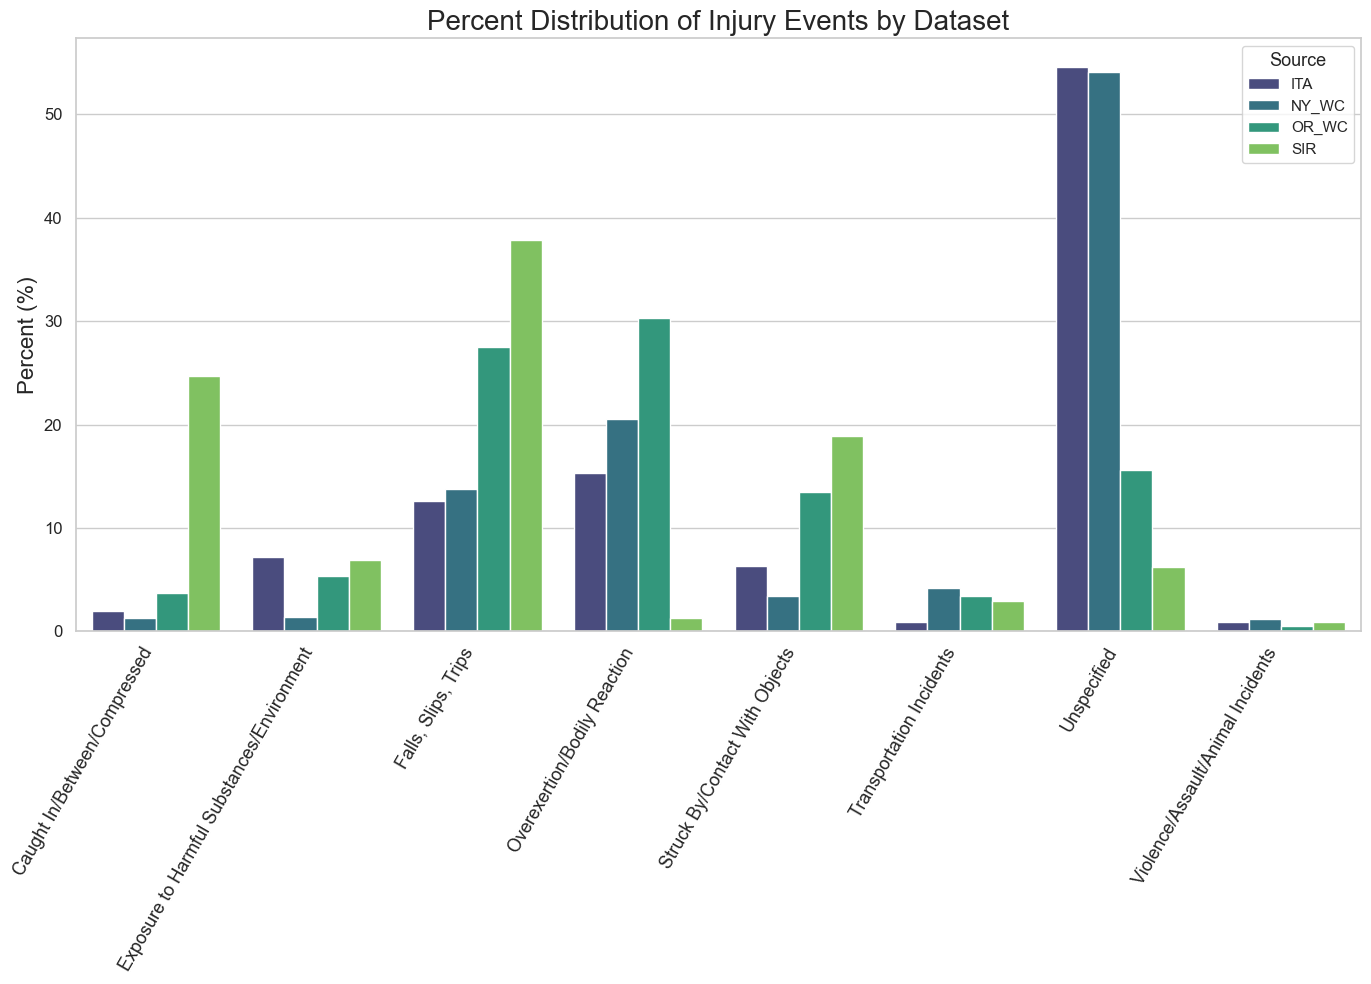

In [41]:
# Event-category proportions within each source dataset.
df_evt = (harmonized.groupby(["source", "event_label"]).size().reset_index(name="count"))
df_evt["percent"] = (df_evt.groupby("source")["count"].transform(lambda x: 100 * x / x.sum()))

plt.figure(figsize=(14, 10))
ax = sns.barplot(data=df_evt, x="event_label", y="percent", hue="source", palette="viridis")
plt.xticks(rotation=60, ha='right', fontsize=13)
plt.yticks(fontsize=12)
plt.title("Percent Distribution of Injury Events by Dataset", fontsize=20)
plt.ylabel("Percent (%)", fontsize=16)
plt.xlabel("")
plt.legend(title="Source", title_fontsize=13, fontsize=11)
plt.tight_layout()

plt.savefig("plots/harmonized_event_type_distribution.png", dpi=600, bbox_inches="tight")
plt.show()

### Nature of Injury by Body Part (Row-Normalized Heatmap)

This heatmap shows the within-body-part distribution of harmonized nature categories.

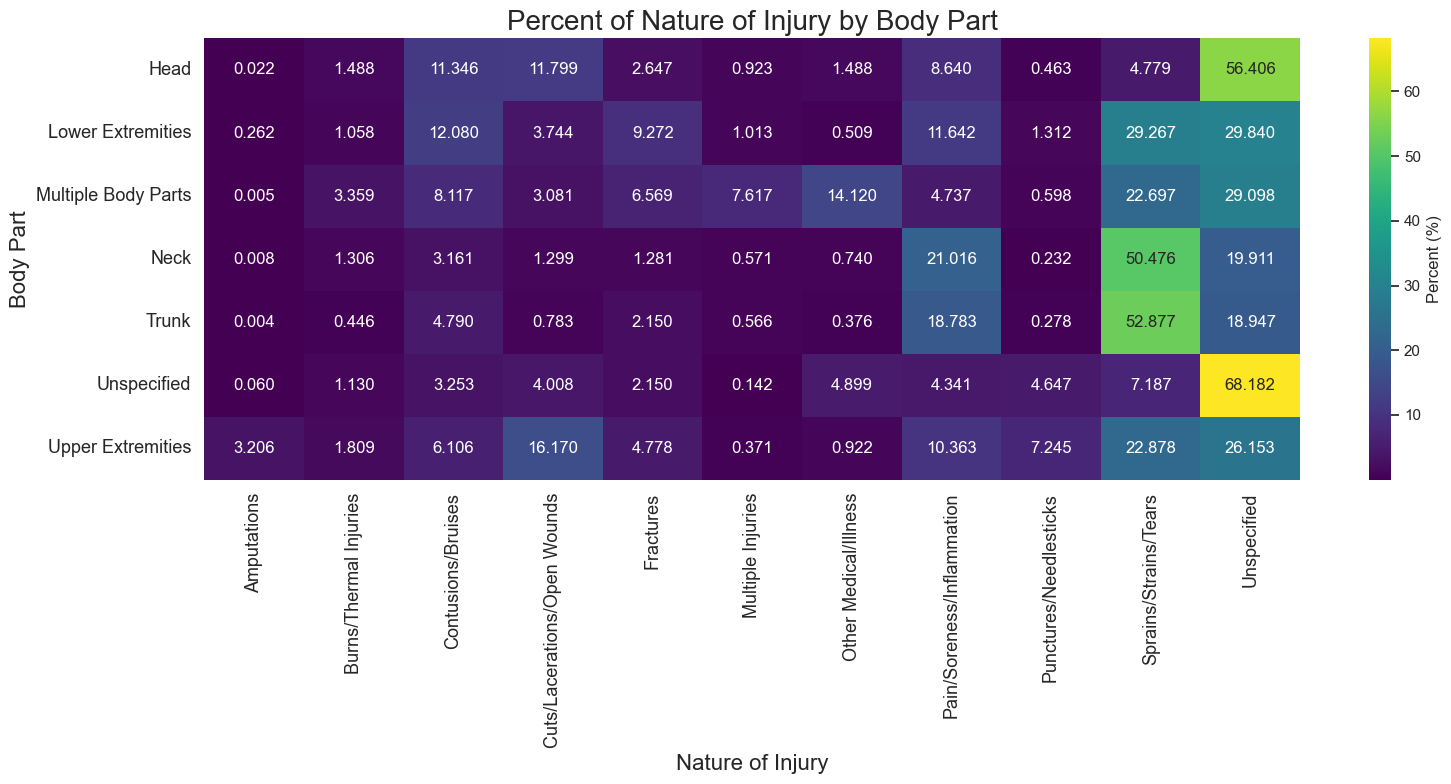

In [42]:
# Cross tab body part and injury nature, then row-normalize for comparability.
pivot = (harmonized.pivot_table(index="body_part_label", columns="nature_label",
                                values="date_of_injury", aggfunc="count", fill_value=0))
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0)

plt.figure(figsize=(16,8))
sns.heatmap(pivot_pct * 100, annot=True, fmt=".3f", cmap="viridis", cbar_kws={"label": "Percent (%)"})
plt.title("Percent of Nature of Injury by Body Part", fontsize=20)
plt.xlabel("Nature of Injury", fontsize=16)
plt.ylabel("Body Part", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()

plt.savefig("plots/harmonized_percent_of_nature_of_injury_by_body_part.png", dpi=600, bbox_inches="tight")
plt.show()

### Injuries Over Time (Raw Monthly Counts by Year)

The time-series view below uses raw monthly counts from records with valid dates and usable industry coding.

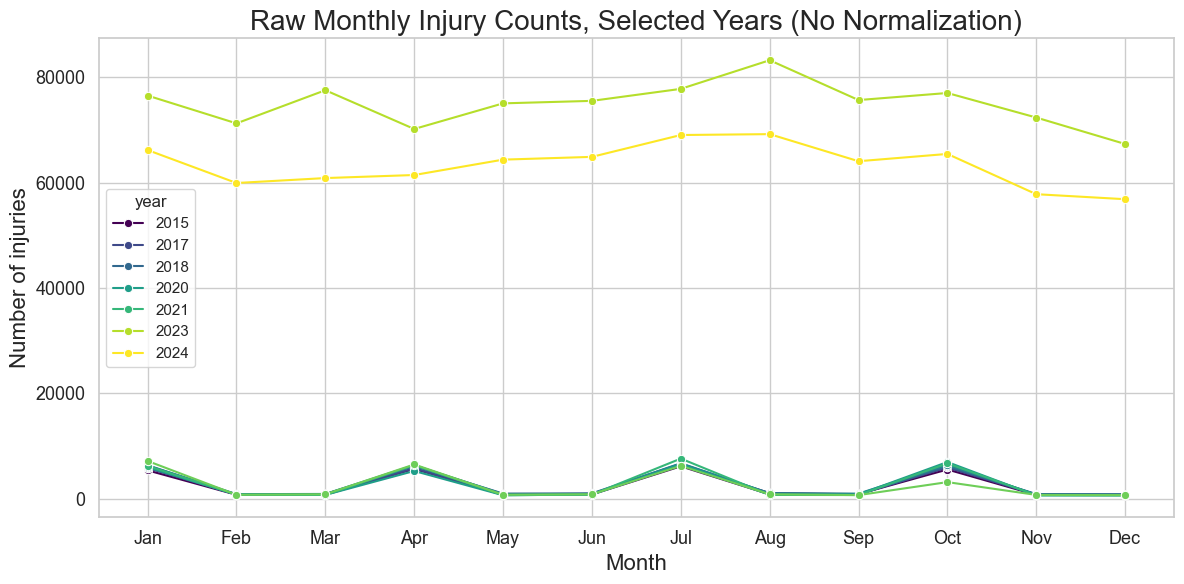

In [43]:
# Drop rows without dates or NAICS and exclude NAICS 9999 (nonclassifiable).
harmonized_sorted = (harmonized.dropna(subset=["date_of_injury", "naics"], how="any").loc[lambda d: d["naics"] != 9999])
harmonized_sorted = harmonized_sorted.sort_values("date_of_injury", ascending=True)
harmonized_sorted = harmonized_sorted[harmonized_sorted["date_of_injury"].dt.year >= 2015]

pre_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]
subset = harmonized_sorted[harmonized_sorted["date_of_injury"].dt.year.isin(pre_years)]

monthly_raw = (subset.groupby(subset["date_of_injury"].dt.to_period("M")).size().reset_index(name="count"))
monthly_raw["month_dt"] = monthly_raw["date_of_injury"].dt.to_timestamp()
monthly_raw["year"] = monthly_raw["month_dt"].dt.year
monthly_raw["month"] = monthly_raw["month_dt"].dt.month

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_raw, x="month", y="count", hue="year", marker="o", palette="viridis")

plt.xticks(ticks=range(1, 13),
           labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.xlabel("Month", fontsize=16)
plt.ylabel("Number of injuries", fontsize=16)
plt.title("Raw Monthly Injury Counts, Selected Years (No Normalization)", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()

plt.savefig("plots/harmonized_raw_monthly_injury_counts_selected_years.png", dpi=600, bbox_inches="tight")
plt.show()

### Injuries by Industry (NAICS Aggregation)

These plots summarize the most common industries within each source and the distribution of event categories within high-frequency industries.

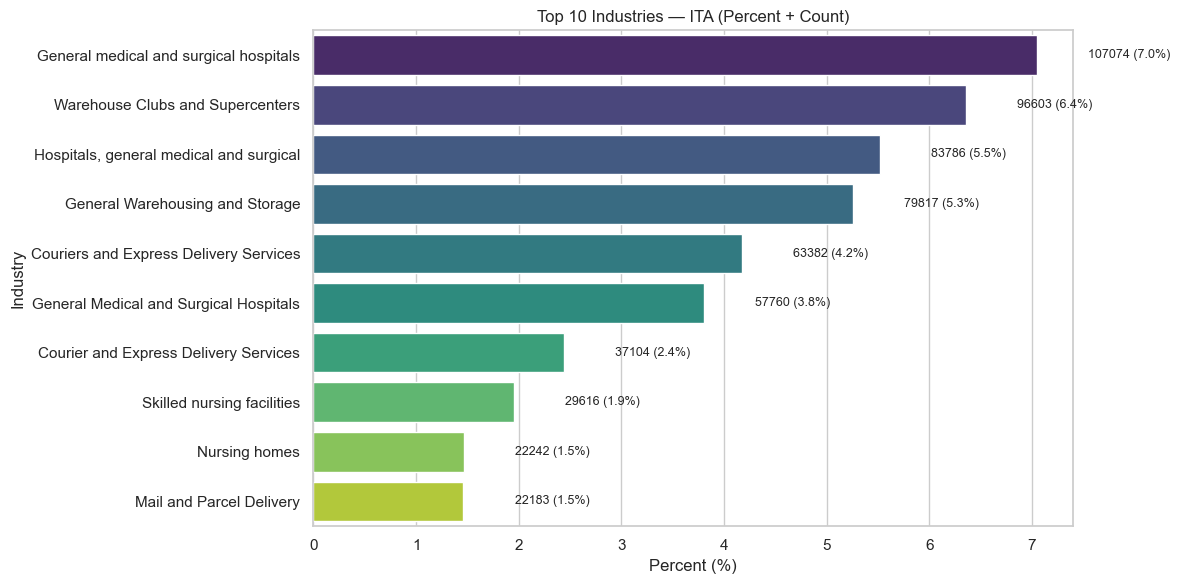

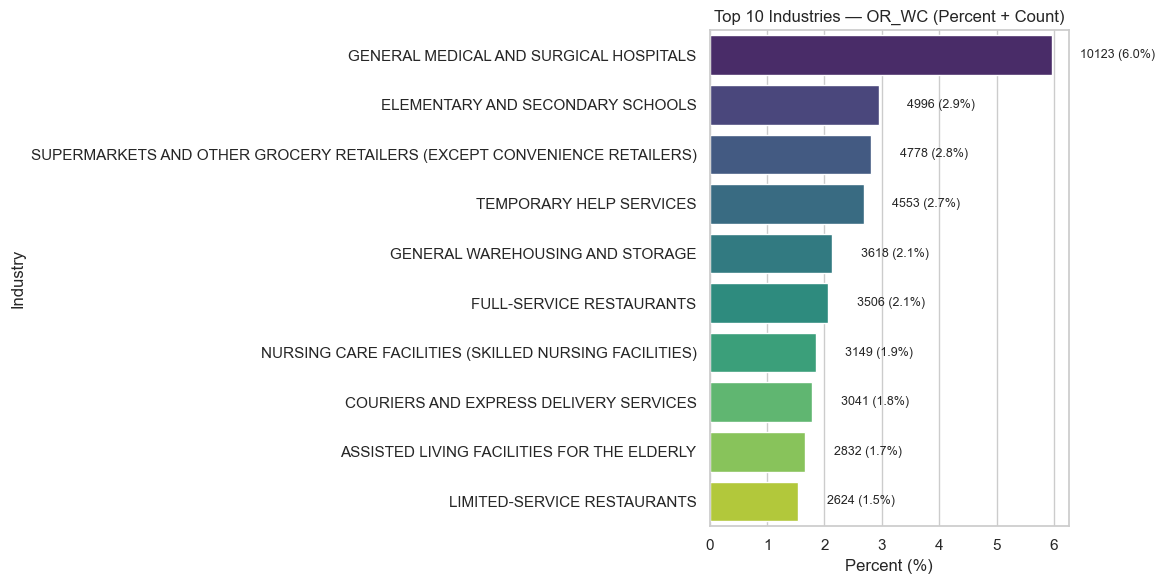

In [44]:
# Summarize the most common industries within each source dataset.
df_ind = (harmonized.groupby(["source", "industry_description"]).size().reset_index(name="count"))

df_ind["industry_description"] = df_ind["industry_description"].fillna("Unspecified")
df_ind["percent"] = (df_ind.groupby("source")["count"].transform(lambda x: 100 * x / x.sum()))

sources = df_ind["source"].unique().tolist()

for src in sources:
    df_src = df_ind[df_ind["source"] == src].copy()
    df_top10 = df_src.nlargest(10, "count").copy()
    df_top10["label"] = (df_top10["count"].astype(int).astype(str) + " (" + df_top10["percent"].round(1).astype(str) + "%)")
    df_top10 = df_top10.sort_values("percent", ascending=False)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_top10, x="percent", y="industry_description", hue="industry_description", palette="viridis")

    for i, row in df_top10.iterrows():
        ax.text(row["percent"] + 0.5, df_top10.index.get_loc(i), row["label"], va="center", ha="left", fontsize=9)

    plt.title(f"Top 10 Industries — {src} (Percent + Count)")
    plt.xlabel("Percent (%)")
    plt.ylabel("Industry")
    plt.tight_layout()
    plt.show()

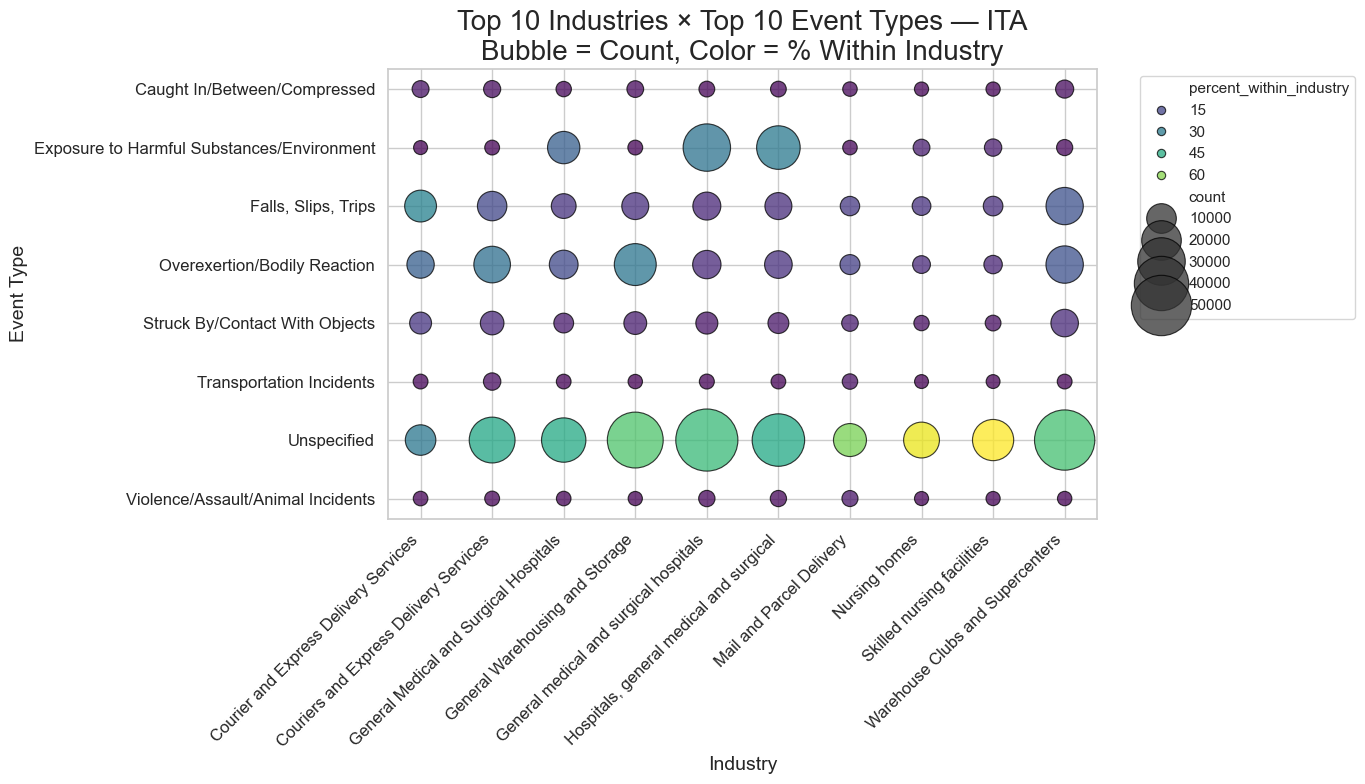

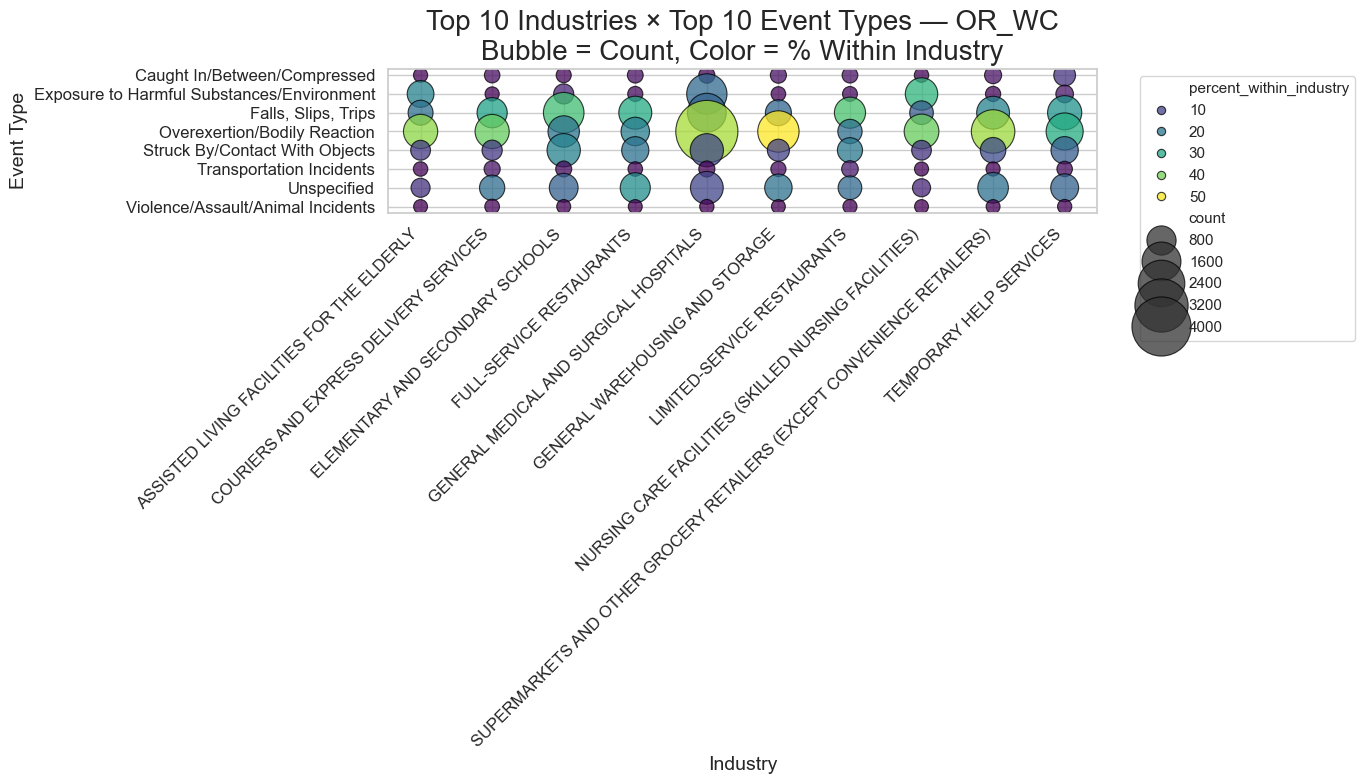

In [45]:
# Show which event categories dominate within the most common industries for each source.
df_evt = (harmonized.groupby(["source", "industry_description", "event_label"]).size().reset_index(name="count"))

df_evt["industry_description"] = df_evt["industry_description"].fillna("Unspecified")
df_evt["event_label"] = df_evt["event_label"].fillna("Unspecified")

df_evt["percent_within_industry"] = (df_evt.groupby(["source", "industry_description"])["count"].transform(lambda x: 100 * x / x.sum()))

sources = df_evt["source"].unique().tolist()

for src in sources:
    df_src = df_evt[df_evt["source"] == src].copy()
    top10_industries = (df_src.groupby("industry_description")["count"].sum().sort_values(ascending=False).head(10).index)
    df_top10_ind = df_src[df_src["industry_description"].isin(top10_industries)].copy()
    top10_events = (df_top10_ind.groupby("event_label")["count"].sum().sort_values(ascending=False).head(10).index)
    df_plot = df_top10_ind[df_top10_ind["event_label"].isin(top10_events)].copy()

    plt.figure(figsize=(14, 8))
    ax = sns.scatterplot(data=df_plot, x="industry_description", y="event_label", size="count",
                         hue="percent_within_industry", sizes=(100, 2000), palette="viridis",
                         alpha=0.75, edgecolor="black")

    plt.title(f"Top 10 Industries × Top 10 Event Types — {src}\n"
              "Bubble = Count, Color = % Within Industry", fontsize=20)
    plt.xlabel("Industry", fontsize=14)
    plt.ylabel("Event Type", fontsize=14)
    plt.xticks(rotation=45, ha="right", fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

#### Tabular Outputs

These quick tabulations (for the above plots) provide some numeric checks that correspond to the visual summaries.

In [53]:
# Overall industry proportions across the harmonized dataset.
overall_ind_pct = (harmonized["industry_description"].value_counts(normalize=True))
overall_ind_pct.head(20)

industry_description
General medical and surgical hospitals                        0.063399
Warehouse Clubs and Supercenters                              0.057199
Hospitals, general medical and surgical                       0.049610
General Warehousing and Storage                               0.047260
Couriers and Express Delivery Services                        0.037529
General Medical and Surgical Hospitals                        0.034200
Courier and Express Delivery Services                         0.021969
Skilled nursing facilities                                    0.017536
Nursing homes                                                 0.013170
Mail and Parcel Delivery                                      0.013135
Wholesale Grocer                                              0.010229
General warehousing and storage                               0.009799
Scheduled Air Transportation                                  0.009493
Grocery Store                                           

In [54]:
# Top harmonized injury-nature labels.
harmonized["nature_label"].value_counts().head(10)

nature_label
Unspecified                     757494
Sprains/Strains/Tears           544148
Pain/Soreness/Inflammation      234280
Cuts/Lacerations/Open Wounds    187085
Contusions/Bruises              154957
Fractures                       102105
Punctures/Needlesticks           81584
Other Medical/Illness            40779
Burns/Thermal Injuries           30078
Amputations                      27229
Name: count, dtype: int64

In [51]:
# Event-by-nature cross-tabulation.
pd.crosstab(harmonized["event_label"], harmonized["nature_label"])

nature_label,Amputations,Burns/Thermal Injuries,Contusions/Bruises,Cuts/Lacerations/Open Wounds,Fractures,Multiple Injuries,Other Medical/Illness,Pain/Soreness/Inflammation,Punctures/Needlesticks,Sprains/Strains/Tears,Unspecified
event_label,,,,,,,,,,,
Caught In/Between/Compressed,16955,202,6188,8240,8731,352,485,3210,373,3953,18358
Exposure to Harmful Substances/Environment,33,7522,168,4763,151,97,20157,2466,50658,618,51631
"Falls, Slips, Trips",1609,885,38775,13833,44053,4521,3011,26968,1435,70315,122829
Overexertion/Bodily Reaction,150,1396,9031,12669,3899,2815,2640,57857,1983,172652,94552
Struck By/Contact With Objects,5017,4266,21371,18164,10975,1563,1671,9965,2550,15400,64265
Transportation Incidents,230,279,3470,1085,2696,1715,547,2594,65,13199,9028
Unspecified,3185,15445,75095,127225,31205,6114,11507,130287,21956,266955,385236
Violence/Assault/Animal Incidents,50,83,859,1106,395,134,761,933,2564,1056,11595


In [55]:
# Most common industry descriptions in the harmonized dataset.
harmonized.groupby("industry_description").size().sort_values(ascending=False).head(10)

industry_description
General medical and surgical hospitals     107074
Warehouse Clubs and Supercenters            96603
Hospitals, general medical and surgical     83786
General Warehousing and Storage             79817
Couriers and Express Delivery Services      63382
General Medical and Surgical Hospitals      57760
Courier and Express Delivery Services       37104
Skilled nursing facilities                  29616
Nursing homes                               22242
Mail and Parcel Delivery                    22183
dtype: int64

## Baseline Modeling (Exploration/Demonstration)

This section builds and evaluates a simple binary target for fall-related events and fits a traditional baseline classifier. This modeling is included as an exploratory reproducibility example/demo rather than as a main contribution (which is more the data harmonization).

Note that the Target variable, `fall_event`, is a binary indicator derived from the harmonized `event_category` field.

In [56]:
harmonized.shape

(2177050, 15)

In [57]:
df = harmonized.copy()

In [58]:
# Get month names for a simple categorical temporal feature.
df["month_name"] = pd.to_datetime(df['month'], format='%Y-%m').dt.month_name()

In [59]:
# Define the binary outcome used in the exploratory baseline model.
df["fall_event"] = (df["event_category"] == "fall").astype(int)
y = df["fall_event"]

In [60]:
y.value_counts()

fall_event
0    1848816
1     328234
Name: count, dtype: int64

In [61]:
# Use only simple categorical features available in the harmonized table.
feature_cols = ["month_name", "industry_description", "nature_category", "body_part_category"]
X = df[feature_cols]

In [63]:
# Split train/test by source to reduce leakage across datasets.
groups = df["source"]

gss = GroupShuffleSplit(test_size=0.2, random_state=1984)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [64]:
print("Train sources:", df.iloc[train_idx]["source"].unique())
print("Test sources:", df.iloc[test_idx]["source"].unique())

Train sources: ['ITA' 'SIR' 'NY_WC']
Test sources: ['OR_WC']


In [65]:
categorical_cols = [
    "industry_description",
    "nature_category",
    "body_part_category",
    "month_name",
]

# Ordinal encoding is sufficient for the decision-tree baseline.
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_final = encoder.fit_transform(X_train[categorical_cols])
X_test_final = encoder.transform(X_test[categorical_cols])

# Other alternatives retained for experimentation:
# encoder = OneHotEncoder(handle_unknown="ignore")
# X_cat_train = encoder.fit_transform(X_train[categorical_cols])
# X_cat_test = encoder.transform(X_test[categorical_cols])
# X_train_final = X_cat_train
# X_test_final = X_cat_test

In [66]:
model = DecisionTreeClassifier(max_depth=None, class_weight="balanced", min_samples_leaf=50, random_state=1984)
model.fit(X_train_final, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1984
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [ ]:
# model = LogisticRegression(max_iter=1000, class_weight="balanced")
# model.fit(X_train_final, y_train)

In [67]:
y_prob = model.predict_proba(X_test_final)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

ROC-AUC: 0.684
PR-AUC: 0.415


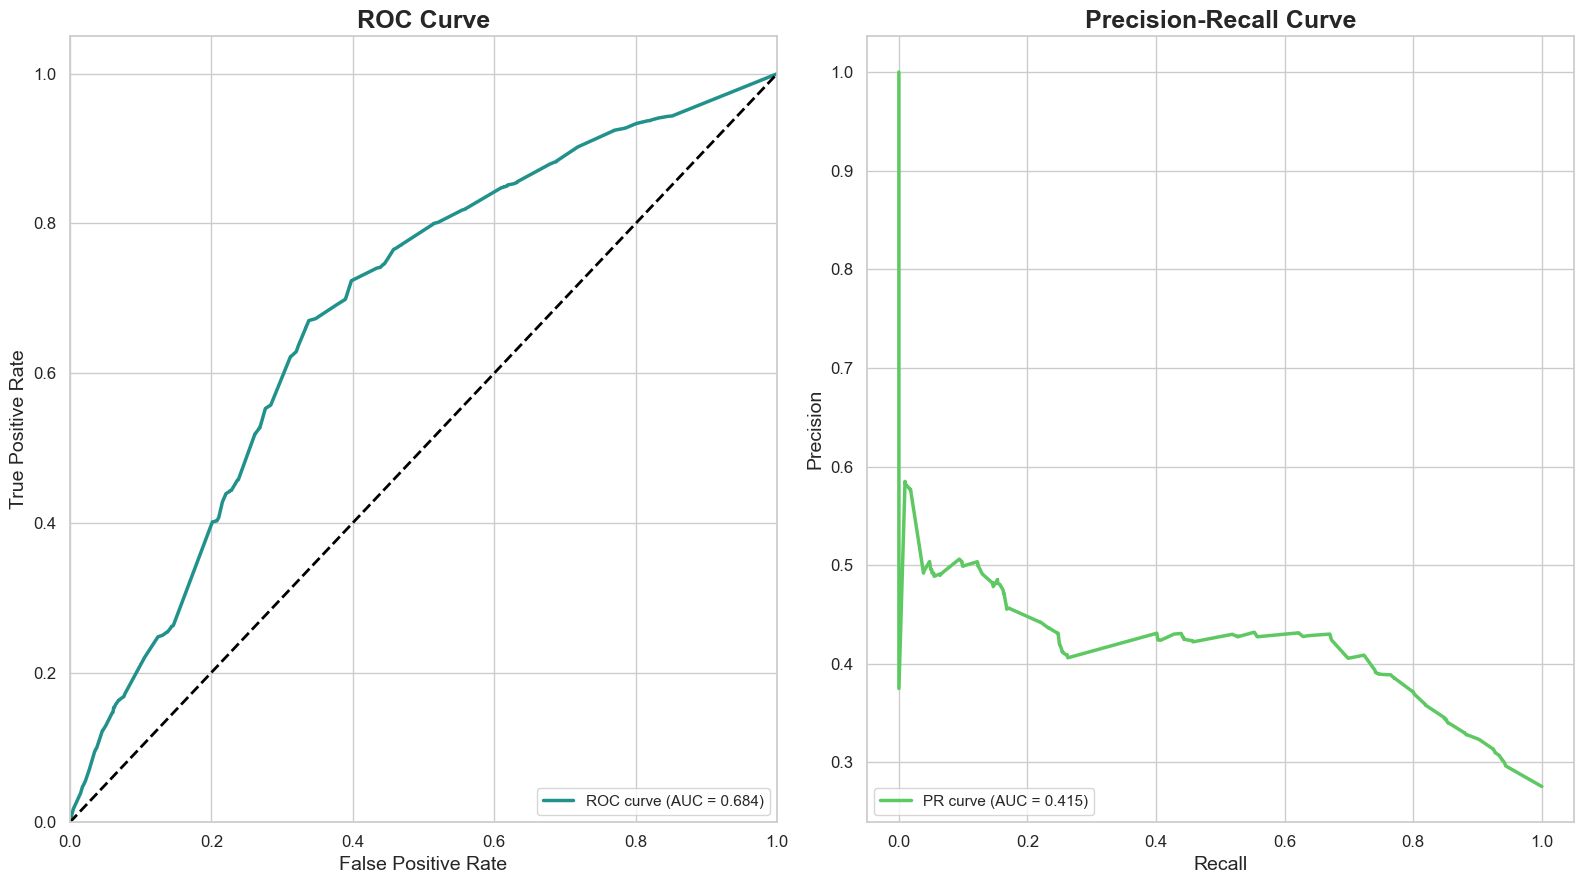

In [68]:
sns.set_style("whitegrid")

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_value = auc(fpr, tpr)
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

viridis_colors = sns.color_palette("viridis", 3)
roc_color = viridis_colors[1]
pr_color = viridis_colors[2]

plt.figure(figsize=(16, 9))

# Panel 1: ROC curve.
plt.subplot(1, 2, 1)
sns.lineplot(x=fpr, y=tpr, color=roc_color, linewidth=2.5, label=f"ROC curve (AUC = {roc_auc_value:.3f})")
plt.plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.title("ROC Curve", fontsize=18, fontweight="bold")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc="lower right", fontsize=11, title_fontsize=12)

# Panel 2: precision-recall curve.
plt.subplot(1, 2, 2)
sns.lineplot(x=recall_vals, y=precision_vals, color=pr_color, linewidth=2.5, label=f"PR curve (AUC = {pr_auc:.3f})")
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)
plt.title("Precision-Recall Curve", fontsize=18, fontweight="bold")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc="lower left", fontsize=11, title_fontsize=12)
plt.tight_layout(h_pad=3.0)

plt.savefig("plots/harmonized_roc_pr_curves.png", dpi=600, bbox_inches="tight")
plt.show()

### Optional Additional Validation (Exploratory Only)

This optional check trains on SIR and evaluates transfer to OR_WC. It is included as a simple source-to-source usability sanity check.

In [69]:
# Train on SIR and test on OR_WC for a simple external validation check.
df_sir_train = df[df["source"] == "SIR"]
df_external_test = df[df["source"].isin(["OR_WC"])]

X_train = df_sir_train[feature_cols].copy()
y_train = df_sir_train["fall_event"]

X_test = df_external_test[feature_cols].copy()
y_test = df_external_test["fall_event"]

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])

In [70]:
# Fit the same decision-tree configuration.
tree = DecisionTreeClassifier(max_depth=None, min_samples_leaf=50, random_state=1984, class_weight="balanced")
tree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,50
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1984
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [71]:
y_prob = tree.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"ROC-AUC (DecisionTree SIR-only -> OR_WC): {roc_auc:.3f}")
print(f"PR-AUC (DecisionTree SIR-only -> OR_WC): {pr_auc:.3f}")

ROC-AUC (DecisionTree SIR-only -> OR_WC): 0.709
PR-AUC (DecisionTree SIR-only -> OR_WC): 0.428


## Appendix

In [80]:
# Optional event distribution figures
def event_dist(df_h: pd.DataFrame, category_col: str = "event_category", source_col: str = "source_dataset",
               normalize: bool = True, layout: str = "facets", out_path: str = "figure_B.png"):
    d = (df_h[[source_col, category_col]].dropna()
         .assign(**{category_col: lambda x: x[category_col].astype(str)})
         .groupby([source_col, category_col]).size()
         .reset_index(name="count")
         )

    if normalize:
        d["value"] = d["count"] / d.groupby(source_col)["count"].transform("sum")
        ylab = "Proportion"
    else:
        d["value"] = d["count"]
        ylab = "Count"

    cat_order = d.groupby(category_col)["count"].sum().sort_values(ascending=False).index.tolist()
    sources = d[source_col].unique().tolist()

    if layout == "facets":
        n = len(sources)
        ncols = 2
        nrows = int(np.ceil(n / ncols))
        facet_w = 6.0
        facet_h = 4.2

        fig, axes = plt.subplots(nrows, ncols, figsize=(facet_w * ncols, facet_h * nrows), 
                                 sharex=True, sharey=True)
        axes = np.array(axes).reshape(-1)

        for ax, s in zip(axes, sources):
            sub = d[d[source_col] == s].set_index(category_col).reindex(cat_order).reset_index()
            ax.bar(sub[category_col], sub["value"], color='purple')
            ax.set_title(str(s), fontsize=11)
            ax.tick_params(axis="x", labelrotation=60)
            ax.set_xlabel("")
            ax.set_ylabel(ylab)
        for ax in axes[len(sources):]:
            ax.axis("off")
        fig.tight_layout()
        plt.show()

    elif layout == "grouped":
        pivot = d.pivot(index=category_col, columns=source_col, values="value").reindex(cat_order)
        ax = pivot.plot(kind="bar", figsize=(12, 6))
        ax.set_ylabel(ylab)
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelrotation=60)
        plt.tight_layout()
        plt.show()

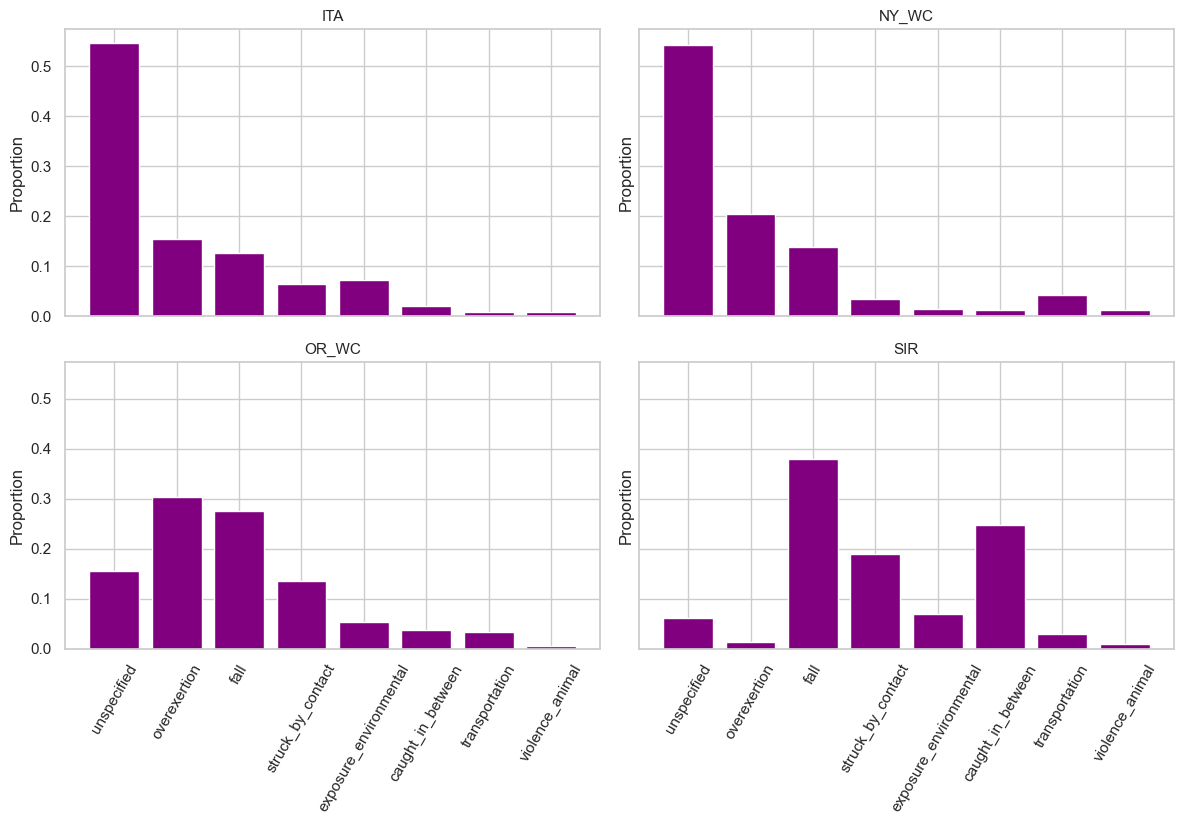

In [81]:
event_dist(harmonized, category_col="event_category", source_col="source")